In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
atendimentos = pd.read_csv("atendimentos.csv")
avaliacoes = pd.read_csv("avaliacoes.csv")
campanhas = pd.read_csv("campanhas_corrigido.csv")
produtos = pd.read_csv("produtos_completo.csv")
tabela_final = pd.read_csv("tabelafinal.csv")
vendas = pd.read_csv('vendas.csv')
clientes = pd.read_csv('clientes.csv')  




In [73]:
atendimentos.drop_duplicates(inplace=True)
avaliacoes.drop_duplicates(inplace=True)
campanhas.drop_duplicates(inplace=True)
produtos.drop_duplicates(inplace=True)
tabela_final.drop_duplicates(inplace=True)

In [74]:
vendas1 = pd.read_csv('venda 1.csv')
vendas2 = pd.read_csv('venda 2.csv' )
vendas3 = pd.read_csv('venda 3.csv' )
df_vendas = pd.concat([vendas, vendas1, vendas2, vendas3], ignore_index=True)


In [75]:
clientes_vendas = pd.merge(df_vendas, clientes, on="ID_Cliente", how="left")
tabela_final = pd.merge(clientes_vendas, produtos, on="ID_Produto", how="left")

In [76]:
tabela_final['Data'] = tabela_final['Data'].astype(str).str.replace(' 00:00:00', '', regex=False)


In [77]:
tabela_final

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,Nome,Idade,Sexo,Cidade,Estado,Canal_Aquisicao,Nome_Produto,Categoria,Preco,Marca
0,1,350,45,2022-09-23,4,Online,5795.64,Davi Luiz Peixoto,39,F,Rio de Janeiro,MG,Loja Física,Fritadeira Airfryer Mondial,Móveis,1448.91,Mondial
1,2,925,68,2024-02-09,1,Loja Física,4614.41,Murilo Cunha,28,M,Porto Alegre,PR,Online,Monitor LG Ultrawide,Eletrodomésticos,4614.41,LG
2,3,915,75,2022-09-11,4,Online,2057.48,Jade Freitas,30,M,Porto Alegre,RJ,Loja Física,Chromecast Google,Informática,514.37,Google
3,4,494,47,2024-05-10,4,Loja Física,12864.44,Kevin Casa Grande,51,F,Curitiba,PR,Loja Física,Máquina de Barbear Philips,Informática,3216.11,Philips
4,5,523,79,2023-10-15,4,Loja Física,13317.28,Asafe Mendonça,29,F,Porto Alegre,SP,Loja Física,Notebook Acer Aspire,Informática,3329.32,Acer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,23195,99,68,2024-11-06,2,Online,922882.00,Ana Lívia Pereira,46,M,São Paulo,RS,Loja Física,Monitor LG Ultrawide,Eletrodomésticos,4614.41,LG
23996,23196,225,90,2024-10-14,2,Loja Física,653663.00,Ana Clara Cirino,54,F,Belo Horizonte,RJ,Online,Tablet Samsung Galaxy Tab,Móveis,3150.89,Samsung
23997,23197,974,15,2024-12-29,4,Loja Física,1256521.00,Yasmin Pimenta,66,F,São Paulo,PR,Online,"Monitor Samsung 24""",Eletrônicos,2946.66,Samsung
23998,23198,269,44,2025-06-13,3,Loja Física,983499.00,Ester Azevedo,37,M,Belo Horizonte,PR,Loja Física,Luminária LED,Eletrônicos,3278.33,Genérico


In [78]:
contagem = tabela_final['Nome_Produto'].value_counts().reset_index()

contagem.sort_values('count', inplace=True)
contagem

,Nome_Produto,count
99,Mouse,44
98,Gabinete Gamer Cooler Master,201
97,Smartwatch Xiaomi,204
96,Volante Logitech G29,209
95,Mouse Gamer Redragon,213
...,...,...
4,Teclado Logitech,271
3,Aspirador de Pó Electrolux,272
1,Pen Drive Sandisk 64GB,272
2,Kindle Paperwhite,272


In [79]:
count_array = np.array(contagem['count'])

q1 = np.percentile(count_array, 25)
q3 = np.percentile(count_array, 75)
media = np.mean(count_array)
mediana = np.median(count_array)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers_inferior = contagem[contagem['count'] < q1]
outliers_superior = contagem[contagem['count'] > q3]


In [80]:
limite_superior

np.float64(285.75)

In [81]:
produtos_venda = tabela_final.groupby("Nome_Produto")["Valor_Total"].sum().reset_index()
media_vendas = produtos_venda["Valor_Total"].mean()
abaixo_media = produtos_venda[produtos_venda["Valor_Total"] < media_vendas]
abaixo_media.sort_values("Valor_Total", inplace=True)

C:\Users\mozar\AppData\Local\Temp\ipykernel_6648\3348260475.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abaixo_media.sort_values("Valor_Total", inplace=True)


  faixa_etaria   valor_total  percentual
0       Adulto  1.391588e+08       80.82
1        Idoso  1.440170e+07        8.36
2        Jovem  1.863166e+07       10.82


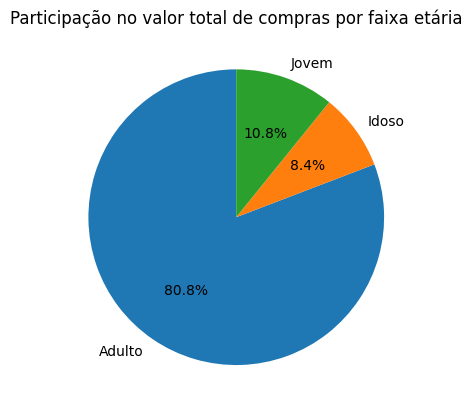

In [82]:

tabela_final["valor_total"] = tabela_final["Quantidade"] * tabela_final["Preco"]


tabela_final["faixa_etaria"] = "Adulto"      
tabela_final.loc[tabela_final["Idade"] < 23, "faixa_etaria"] = "Jovem"
tabela_final.loc[tabela_final["Idade"] > 65, "faixa_etaria"] = "Idoso"

perfil = tabela_final.groupby("faixa_etaria")["valor_total"].sum().reset_index()

total = perfil["valor_total"].sum()
perfil["percentual"] = (perfil["valor_total"] / total * 100).round(2)

print(perfil)

plt.pie(
    perfil["valor_total"],
    labels=perfil["faixa_etaria"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participação no valor total de compras por faixa etária")
plt.show()


In [83]:
perfil_sexo = tabela_final.groupby("Sexo")["valor_total"].sum().reset_index()
total = perfil_sexo["valor_total"].sum()
perfil_sexo["percentual"] = (perfil_sexo["valor_total"] / total * 100).round(2)


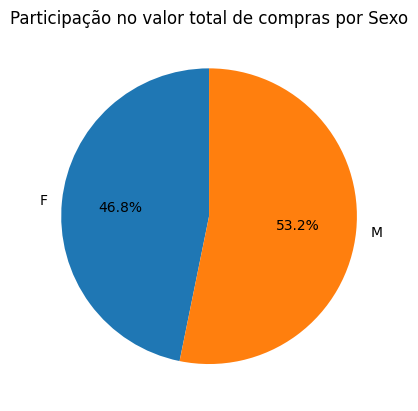

In [84]:
plt.pie(
    perfil_sexo["valor_total"],
    labels=perfil_sexo["Sexo"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participação no valor total de compras por Sexo")
plt.show()

In [85]:
perfil_canal = tabela_final.groupby("Canal_Aquisicao")["valor_total"].sum().reset_index()
total = perfil_canal["valor_total"].sum()
perfil_canal["percentual"] = (perfil_canal["valor_total"] / total * 100).round(2)

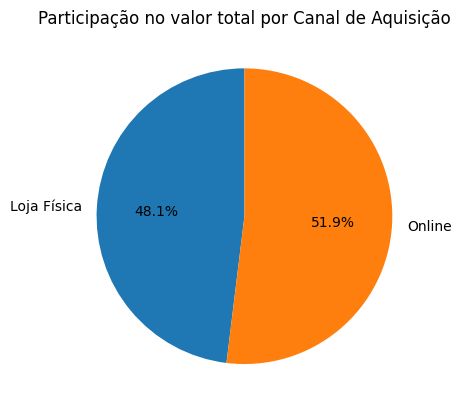

In [86]:
plt.pie(
    perfil_canal["valor_total"],
    labels=perfil_canal["Canal_Aquisicao"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participação no valor total por Canal de Aquisição")
plt.show()

In [87]:
perfil_cidade = tabela_final.groupby("Cidade")["valor_total"].sum().reset_index()
total = perfil_cidade["valor_total"].sum()
perfil_cidade["percentual"] = (perfil_cidade["valor_total"] / total * 100).round(2)


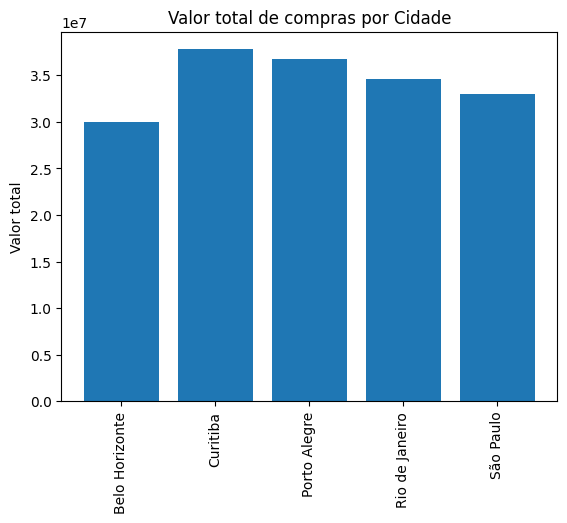

In [88]:
plt.bar(perfil_cidade["Cidade"], perfil_cidade["valor_total"])
plt.xticks(rotation=90)
plt.title("Valor total de compras por Cidade")
plt.ylabel("Valor total")
plt.show()

In [89]:
perfil_estado = tabela_final.groupby("Estado")["valor_total"].sum().reset_index()
total = perfil_estado["valor_total"].sum()
perfil_estado["percentual"] = (perfil_estado["valor_total"] / total * 100).round(2)

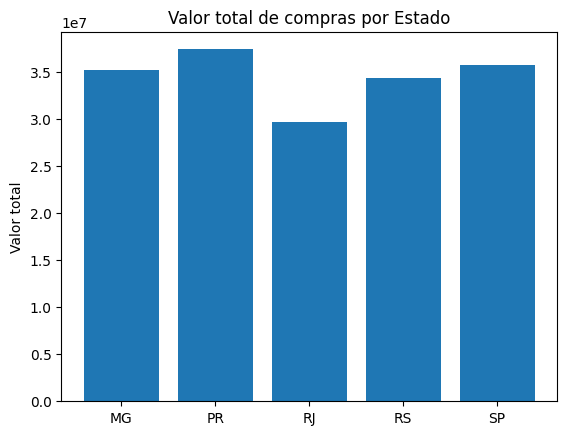

In [90]:
plt.bar(perfil_estado["Estado"], perfil_estado["valor_total"])
plt.title("Valor total de compras por Estado")
plt.ylabel("Valor total")
plt.show()


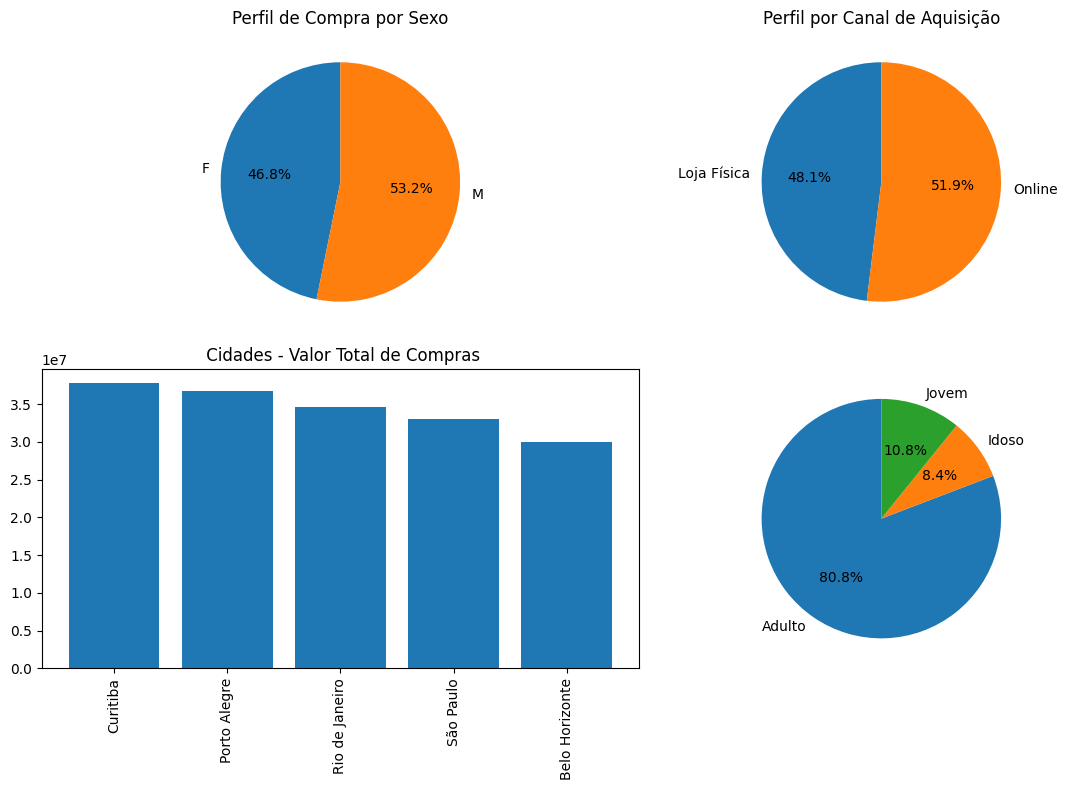

<Figure size 640x480 with 0 Axes>

In [91]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))



axs[0, 0].pie(
    perfil_sexo["valor_total"],
    labels=perfil_sexo["Sexo"],
    autopct="%1.1f%%",
    startangle=90
)
axs[0, 0].set_title("Perfil de Compra por Sexo")

# --- Gráfico 2: Canal de Aquisição (Pizza)
axs[0, 1].pie(
    perfil_canal["valor_total"],
    labels=perfil_canal["Canal_Aquisicao"],
    autopct="%1.1f%%",
    startangle=90
)
axs[0, 1].set_title("Perfil por Canal de Aquisição")

# --- Gráfico 3: Cidades (Barra - 10 principais)
top_cidades = perfil_cidade.sort_values("valor_total", ascending=False).head(10)
axs[1, 0].bar(top_cidades["Cidade"], top_cidades["valor_total"])
axs[1, 0].set_title(" Cidades - Valor Total de Compras")
axs[1, 0].tick_params(axis="x", rotation=90)

# --- Gráfico 4: Estado (Barra)
axs[1, 1].pie(
    perfil["valor_total"],
    labels=perfil["faixa_etaria"],
    autopct="%1.1f%%",
    startangle=90
)
# Ajustar layout
plt.tight_layout()
plt.show()
plt.savefig("relatorio_perfis.png", dpi=300, bbox_inches="tight")


In [92]:
tabela_final.to_csv('tabela_final.csv', index=False)
